In [85]:
import torch
from sklearn.model_selection import train_test_split
import pandas as pd
from torch import nn
import matplotlib.pyplot as plt 
import seaborn as sns

In [86]:
df = pd.read_csv("08-seismic_activity_svm.csv")

In [87]:
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


In [89]:
X = df.drop("seismic_event_detected", axis = 1)
y = df["seismic_event_detected"]

In [90]:
X

,underground_wave_energy,vibration_axis_variation
0,9.539392,-3.000000
1,9.558241,-2.939394
2,9.576669,-2.878788
3,9.594678,-2.818182
4,9.612272,-2.757576
...,...,...
395,-4.170824,-2.757576
396,-4.130115,-2.818182
397,-4.088102,-2.878788
398,-4.044745,-2.939394


In [91]:
y.unique()

array([0, 1])

In [92]:
y.value_counts()

seismic_event_detected
0    200
1    200
Name: count, dtype: int64

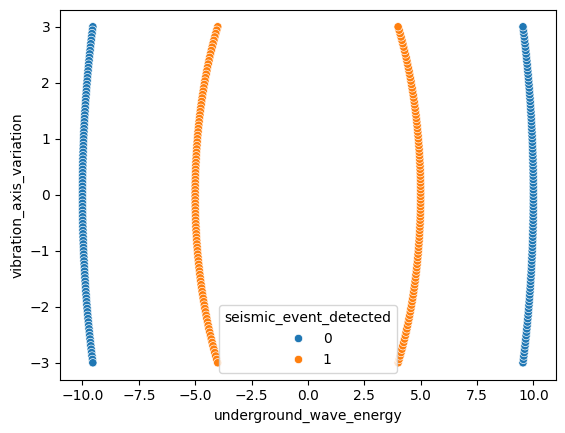

In [93]:
sns.scatterplot(x = df["underground_wave_energy"], y = df["vibration_axis_variation"], hue = y)
plt.show()

In [94]:
X = X.values
y = y.values

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=99)

In [96]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [97]:
X_test.shape

torch.Size([80, 2])

In [98]:
y_test.shape

torch.Size([80, 1])

In [99]:
class NonLinearClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer_1 = nn.Linear(in_features=2, out_features=5)
        self.relu = nn.ReLU()
        self.layer_2 = nn.Linear(in_features=5, out_features=1)

    def forward(self, x):
        return self.layer_2(self.relu(self.layer_1(x)))

In [100]:
model = NonLinearClassificationModel()

In [101]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model.parameters(), lr = 0.1)

In [102]:
def calculate_accuracy(y_test, y_pred):
    correct = torch.eq(y_test, y_pred).sum().item()
    accuracy = correct / len(y_test) * 100
    return accuracy

In [103]:
torch.manual_seed(42)
epochs = 600

epoch_count = []
train_loss_values = []
test_loss_values = []
train_acc_values = []
test_acc_values = []

for epoch in range(epochs):
    model.train()

    # forward pass
    y_logits = model(X_train)
    y_pred = torch.round(torch.sigmoid(y_logits))

    # loss
    loss = loss_fn(y_logits, y_train)
    acc = calculate_accuracy(y_train, y_pred)

    optimizer.zero_grad()

    # backprop
    loss.backward()

    optimizer.step()

    model.eval()
    with torch.inference_mode():
        # forward pass
        test_logits = model(X_test)
        test_pred = torch.round(torch.sigmoid(test_logits))

        # accuracy / loss
        test_loss = loss_fn(test_logits, y_test)
        test_acc = calculate_accuracy(y_test, test_pred)

        epoch_count.append(epoch)
        train_loss_values.append(loss.item()) 
        test_loss_values.append(test_loss.item())
        train_acc_values.append(acc)     
        test_acc_values.append(test_acc)

    if epoch % 20 == 0:
        print(f"Epoch: {epoch}, Loss: {loss:.2f}, Acc: {acc:.2f} -- Test Loss: {test_loss:.2f}, Test Accuracy: {test_acc:.2f}, ")

        

Epoch: 0, Loss: 0.71, Acc: 46.25 -- Test Loss: 0.67, Test Accuracy: 56.25, 
Epoch: 20, Loss: 0.60, Acc: 56.88 -- Test Loss: 0.59, Test Accuracy: 58.75, 
Epoch: 40, Loss: 0.54, Acc: 64.69 -- Test Loss: 0.54, Test Accuracy: 68.75, 
Epoch: 60, Loss: 0.49, Acc: 73.12 -- Test Loss: 0.48, Test Accuracy: 77.50, 
Epoch: 80, Loss: 0.44, Acc: 83.75 -- Test Loss: 0.42, Test Accuracy: 85.00, 
Epoch: 100, Loss: 0.38, Acc: 93.12 -- Test Loss: 0.37, Test Accuracy: 92.50, 
Epoch: 120, Loss: 0.33, Acc: 98.44 -- Test Loss: 0.31, Test Accuracy: 98.75, 
Epoch: 140, Loss: 0.28, Acc: 100.00 -- Test Loss: 0.26, Test Accuracy: 100.00, 
Epoch: 160, Loss: 0.24, Acc: 100.00 -- Test Loss: 0.22, Test Accuracy: 100.00, 
Epoch: 180, Loss: 0.20, Acc: 100.00 -- Test Loss: 0.18, Test Accuracy: 100.00, 
Epoch: 200, Loss: 0.17, Acc: 100.00 -- Test Loss: 0.15, Test Accuracy: 100.00, 
Epoch: 220, Loss: 0.14, Acc: 100.00 -- Test Loss: 0.13, Test Accuracy: 100.00, 
Epoch: 240, Loss: 0.12, Acc: 100.00 -- Test Loss: 0.11, Test

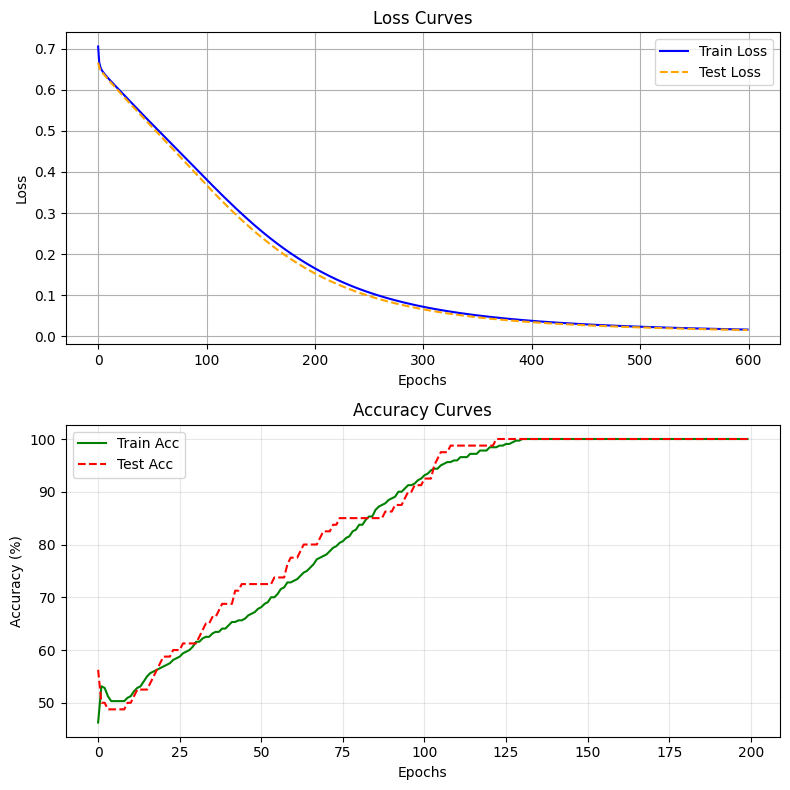

In [107]:
plt.figure(figsize=(8,8))

plt.subplot(2, 1, 1) 
plt.plot(epoch_count, train_loss_values, label="Train Loss", color="blue")
plt.plot(epoch_count, test_loss_values, label="Test Loss", color="orange", linestyle="--")
plt.title("Loss Curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2) # 1 satır, 2 sütun, 2. grafik
plt.plot(epoch_count[:200], train_acc_values[:200], label="Train Acc", color="green")
plt.plot(epoch_count[:200], test_acc_values[:200], label="Test Acc", color="red", linestyle="--")
plt.title("Accuracy Curves")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()